<a href="https://colab.research.google.com/github/allythe/HorizonDetection/blob/main/StatisticalAnalysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Brief Outline

This script performs the **statistical analysis** of results obtained after running the `Algorithms.ipynb` file.  

It includes:

- Displaying **boxplots** of accuracy metrics.
- Performing **pairwise statistical tests** to compare methods.

The analysis is divided into the following parts:

1. **Compute accuracy metrics** – calculate quality measures for all algorithms.  
2. **Draw boxplots** – visualize the distribution of quality metrics across all algorithms.  
3. **Pairwise statistical comparison** – run Mann-Whitney U test with Holm-Bonferroni correction.  
4. **Draw images with predicted horizons** – visualize horizon predictions for selected methods.  
5. **Draw ground truth horizons** – overlay the GT horizon on a single frame from each video for reference.

In [ ]:
pip install path

In [ ]:
import os
import random
import cv2
from PIL import Image

import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from tqdm import tqdm
from path import Path

In [ ]:
from google.colab import drive
drive.mount("/content/drive/")
base_dir = "drive/MyDrive/implementation/"
os.chdir('/content')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


# Compute accuracy metrics

In [ ]:
def compute_accuracy_metrics(gt_dict, pred_dict, images_folder, img_name):

    img_path = os.path.join(images_folder, img_name)
    try:
        # Even faster: Use PIL which only reads header
        with Image.open(img_path) as img:
            width, height = img.size
    except Exception as e:
        # Fallback to cv2 if PIL fails
        import cv2
        img_data = cv2.imread(img_path, cv2.IMREAD_REDUCED_GRAYSCALE_2)
        if img_data is None:
            print(f"Could not load {img_path}")
            return
        height, width = img_data.shape[:2]

    gt_points = gt_dict.get(img_name)
    if gt_points is None:
        print(f"No GT data for {img_name}")
        return

    pred_row = pred_dict.get(img_name)
    if pred_row is None or not pred_row['has_pred']:
        print(f"No prediction for {img_name}")
        return

    x1, y1, x2, y2 = pred_row['coords']
    pred_angle = np.degrees(np.arctan2(y2 - y1, x2 - x1))

    # Compute the number of columns (x-span) for each segment
    segment_spans = np.diff(gt_points[:, 0])  # x2 - x1 for each segment
    total_span = np.sum(segment_spans)

    # Compute weighted mean angle deviation based on x-span
    angle_devs = []
    for i in range(len(gt_points) - 1):
        gx1, gy1 = gt_points[i]
        gx2, gy2 = gt_points[i + 1]
        segment_angle = np.degrees(np.arctan2(gy2 - gy1, gx2 - gx1))
        angle_dev = abs(segment_angle - pred_angle)
        weight = segment_spans[i] / total_span if total_span > 0 else 0
        angle_devs.append(angle_dev * weight)

    mean_angle_dev = np.sum(angle_devs)

    # Interpolate predicted line over overlapping x-range for height deviation
    overlap_x_start = max(min(gt_points[:, 0]), min(x1, x2))
    overlap_x_end = min(max(gt_points[:, 0]), max(x1, x2))
    if overlap_x_end <= overlap_x_start:
        mean_height_dev = np.nan
        coverage_percent = 0
        mean_height_dev = np.nan
    else:
        overlap_xs = np.linspace(overlap_x_start, overlap_x_end, 200)
        gt_y_interp = np.interp(overlap_xs, gt_points[:, 0], gt_points[:, 1])
        m_pred = (y2 - y1) / (x2 - x1) if (x2 - x1) != 0 else None
        b_pred = y1 - m_pred * x1 if m_pred is not None else None
        pred_y_interp = m_pred * overlap_xs + b_pred if m_pred is not None else np.full_like(overlap_xs, np.nan)
        mask = ~np.isnan(pred_y_interp)
        mean_height_dev = np.mean(np.abs(gt_y_interp[mask] - pred_y_interp[mask])) if np.any(mask) else np.nan
        coverage_percent = 100 * (overlap_x_end - overlap_x_start) / width
        mean_height_perc_dev = mean_height_dev/ height

    return {
        "image_name": img_name,
        "mean_height_deviation": mean_height_dev,
        "predicted_coverage_percent": coverage_percent,
        "mean_angle_deviation": mean_angle_dev,
        "mean_height_perc_dev": mean_height_perc_dev
    }

In [ ]:
def compute_accuracy_metrics_all_img(gt_csv, results_csv, images_folder,  save_csv_path):
    gt_df = pd.read_csv(gt_csv)
    pred_df = pd.read_csv(results_csv)


    gt_dict = {}
    for img_name, group in gt_df.groupby('image_name'):
        points = group[['x', 'y']].values
        points = points[np.argsort(points[:, 0])]
        gt_dict[img_name] = points

    pred_dict = {}
    for img_name, group in pred_df.groupby('image_name'):
        row = group.iloc[0]  # Assuming one prediction per image
        pred_dict[img_name] = {
            'coords': row[['x1', 'y1', 'x2', 'y2']].values.astype(float),
            'has_pred': not pd.isna(row['x1'])
        }

    common_imgs = set(gt_df['image_name']).intersection(pred_df['image_name'])
    print(f"Processing {len(common_imgs)} images...")

    all_results = []

    for img_name in tqdm(sorted(common_imgs)):
        try:
          result = compute_accuracy_metrics(gt_dict, pred_dict, images_folder, img_name)
        except:
          print(img_name)
          result = None
        if result is not None:
            time_row = pred_df[pred_df['image_name'] == img_name]
            if not time_row.empty:
                result["time_sec"] = float(time_row.iloc[0]["time_sec"])
            else:
                result["time_sec"] = None
            all_results.append(result)

    df_results = pd.DataFrame(all_results)
    return df_results

## Compute accuracy metrics for H-HC horizon detection results

In [ ]:
gt_csv = Path(base_dir) / Path("results_38_videos/horizon_gt_coordinates_cropped_all.csv")
results_csv = Path(base_dir) / Path("results_38_videos/horizon_hc_all_cropped.csv")

save_csv_path = Path(base_dir)/ Path("results_38_videos/horizon_h_hc_analysis_results.csv")
images_folder = Path(base_dir)/ Path("images_drone")

df_results_h_hc = compute_accuracy_metrics_all_img(gt_csv, results_csv, images_folder, save_csv_path)
df_results_h_hc.to_csv(save_csv_path, index=False)
print(f" All results saved to {save_csv_path}")

Processing 12360 images...


 72%|███████▏  | 8924/12360 [01:02<00:20, 167.49it/s]

boat7_img_000527.jpeg
boat7_img_000534.jpeg


 73%|███████▎  | 8978/12360 [01:14<09:30,  5.93it/s]

boat7_img_000578.jpeg


...

drone8_img_000440.jpeg


100%|█████████▉| 12342/12360 [15:15<00:04,  4.19it/s]

drone8_img_000442.jpeg


100%|██████████| 12360/12360 [15:19<00:00, 13.44it/s]


 All results saved to drive/MyDrive/implementation/results_cropped/horizon_h_hc_analysis_results.csv


In [ ]:
df_results_h_hc.describe()

,mean_height_deviation,predicted_coverage_percent,mean_angle_deviation,mean_height_perc_dev,time_sec
count,12304.000000,12304.000000,12304.000000,12304.000000,12304.000000
mean,119.534557,43.546727,3.246531,0.112646,0.192447
std,201.247770,15.745245,8.085040,0.185982,0.781119
min,0.128060,0.260417,0.000000,0.000119,0.074000
25%,7.037974,32.760417,0.306694,0.006810,0.133000
50%,31.177129,40.781250,0.774260,0.034813,0.170000
75%,144.966828,51.666667,2.182607,0.135921,0.207000
max,1019.195859,99.947917,89.134736,0.943700,75.734000


## Compute accuracy metrics for H-LSC horizon detection results

In [ ]:
results_csv = Path(base_dir) / Path("results_cropped/horizon_h_lsc_all_cropped.csv")
save_csv_path = Path(base_dir)/ Path("results_cropped/horizon_h_lsc_analysis_results.csv")

df_results_h_lsc = compute_accuracy_metrics_all_img(gt_csv, results_csv, images_folder, save_csv_path)
df_results_h_lsc.to_csv(save_csv_path, index=False)
print(f" All results saved to {save_csv_path}")


Processing 12360 images...


100%|██████████| 12360/12360 [01:42<00:00, 120.36it/s]


 All results saved to drive/MyDrive/implementation/results_cropped/horizon_h_lsc_analysis_results.csv


In [ ]:
df_results_h_lsc.describe()

,mean_height_deviation,predicted_coverage_percent,mean_angle_deviation,mean_height_perc_dev,time_sec
count,12360.000000,12360.000000,12360.000000,12360.000000,12360.000000
mean,148.407879,99.944176,4.353492,0.146707,0.074783
std,120.816127,0.009286,4.343075,0.119819,0.512337
min,0.939547,99.864583,0.000016,0.000870,0.026000
25%,55.298844,99.947917,1.262223,0.057344,0.064000
50%,111.764251,99.947917,3.198074,0.108144,0.067000
75%,233.138631,99.947917,6.403138,0.221336,0.074000
max,1470.755914,99.947917,52.518468,1.361811,44.414000


## Compute accuracy metrics for H-MED horizon detection results

In [ ]:
results_csv = Path(base_dir) / Path("results_cropped/horizon_h_med_all_cropped.csv")
save_csv_path =  Path(base_dir)/ Path("results_cropped/horizon_h_med_analysis_results.csv")

df_results_h_med = compute_accuracy_metrics_all_img(gt_csv, results_csv, images_folder, save_csv_path)
df_results_h_med.to_csv(save_csv_path, index=False)
print(f" All results saved to {save_csv_path}")

Processing 12360 images...


100%|██████████| 12360/12360 [01:37<00:00, 126.88it/s]


 All results saved to drive/MyDrive/implementation/results_cropped/horizon_h_med_analysis_results.csv


In [ ]:
df_results_h_med.describe()

,mean_height_deviation,predicted_coverage_percent,mean_angle_deviation,mean_height_perc_dev,time_sec
count,12360.000000,12360.000000,12360.000000,12360.000000,12360.000000
mean,139.636111,99.888646,3.033870,0.139534,0.089005
std,113.587716,0.017883,2.929219,0.120367,0.429281
min,0.511708,99.812500,0.000286,0.000474,0.032000
25%,38.315998,99.895833,0.836453,0.037735,0.077000
50%,104.852523,99.895833,2.029021,0.099562,0.080000
75%,237.534847,99.895833,4.404037,0.219940,0.087000
max,558.007515,99.895833,15.337827,0.516674,37.663000


## Compute accuracy metrics for H-COV-LUM horizon detection results

In [ ]:
results_csv = Path(base_dir) / Path("results_cropped/horizon_h_cov_lum_all_cropped.csv")
save_csv_path =  Path(base_dir)/ Path("results_cropped/horizon_h_cov_lum_analysis_results.csv")
df_results_h_cov_lum = compute_accuracy_metrics_all_img(gt_csv, results_csv, images_folder, save_csv_path)
df_results_h_cov_lum.to_csv(save_csv_path, index=False)
print(f" All results saved to {save_csv_path}")

Processing 12360 images...


100%|██████████| 12360/12360 [01:25<00:00, 143.92it/s]


 All results saved to drive/MyDrive/implementation/results_cropped/horizon_h_cov_lum_analysis_results.csv


In [ ]:
df_results_h_cov_lum.describe()

,mean_height_deviation,predicted_coverage_percent,mean_angle_deviation,mean_height_perc_dev,time_sec
count,12360.000000,12360.000000,12360.000000,12360.000000,12360.000000
mean,227.821983,99.944176,7.042205,0.229449,0.619560
std,186.893607,0.009286,7.482674,0.189335,0.449593
min,0.179998,99.864583,0.000000,0.000167,0.196000
25%,72.247995,99.947917,0.598525,0.066896,0.573000
50%,182.271070,99.947917,5.124076,0.186697,0.599000
75%,363.506214,99.947917,10.452163,0.343922,0.633000
max,895.347711,99.947917,30.344369,0.829026,34.829000


## Compute accuracy metrics for Segment horizon detection results

In [ ]:
results_csv =  Path(base_dir) / Path("results_cropped/horizon_segment_all_cropped.csv")
save_csv_path = Path(base_dir)/ Path("results_cropped/horizon_segment_analysis_results.csv")

df_results_segment = compute_accuracy_metrics_all_img(gt_csv, results_csv, images_folder, save_csv_path)
df_results_segment.to_csv(save_csv_path, index=False)
print(f" All results saved to {save_csv_path}")

Processing 12360 images...


 63%|██████▎   | 7840/12360 [00:56<00:27, 163.79it/s]

No prediction for boat30_img_000005.jpeg
No prediction for boat30_img_000028.jpeg
No prediction for boat30_img_000036.jpeg
No prediction for boat30_img_000037.jpeg
No prediction for boat30_img_000038.jpeg
No prediction for boat30_img_000039.jpeg
No prediction for boat30_img_000040.jpeg
No prediction for boat30_img_000041.jpeg


 64%|██████▍   | 7890/12360 [00:56<00:21, 209.22it/s]

No prediction for boat30_img_000043.jpeg
No prediction for boat30_img_000044.jpeg
No prediction for boat30_img_000047.jpeg
No prediction for boat30_img_000049.jpeg
No prediction for boat30_img_000050.jpeg
No prediction for boat30_img_000051.jpeg
No prediction for boat30_img_000052.jpeg
No prediction for boat30_img_000053.jpeg
No prediction for boat30_img_000054.jpeg
No prediction for boat30_img_000055.jpeg
No prediction for boat30_img_000059.jpeg
No prediction for boat30_img_000060.jpeg
No prediction for boat30_img_000061.jpeg
No prediction for boat30_img_000062.jpeg
No prediction for boat30_img_000063.jpeg
No prediction for boat30_img_000064.jpeg
No prediction for boat30_img_000065.jpeg
No prediction for boat30_img_000066.jpeg
No prediction for boat30_img_000067.jpeg
No prediction for boat30_img_000068.jpeg
No prediction for boat30_img_000069.jpeg
No prediction for boat30_img_000070.jpeg
No prediction for boat30_img_000071.jpeg
No prediction for boat30_img_000072.jpeg
No prediction fo

 64%|██████▍   | 7948/12360 [00:57<00:17, 245.59it/s]

No prediction for boat30_img_000097.jpeg
No prediction for boat30_img_000098.jpeg
No prediction for boat30_img_000099.jpeg
No prediction for boat30_img_000100.jpeg
No prediction for boat30_img_000102.jpeg
No prediction for boat30_img_000103.jpeg
No prediction for boat30_img_000104.jpeg
No prediction for boat30_img_000105.jpeg
No prediction for boat30_img_000106.jpeg
No prediction for boat30_img_000107.jpeg
No prediction for boat30_img_000108.jpeg
No prediction for boat30_img_000109.jpeg
No prediction for boat30_img_000110.jpeg
No prediction for boat30_img_000111.jpeg
No prediction for boat30_img_000112.jpeg
No prediction for boat30_img_000113.jpeg
No prediction for boat30_img_000114.jpeg
No prediction for boat30_img_000115.jpeg
No prediction for boat30_img_000116.jpeg
No prediction for boat30_img_000117.jpeg
No prediction for boat30_img_000118.jpeg
No prediction for boat30_img_000119.jpeg
No prediction for boat30_img_000120.jpeg
No prediction for boat30_img_000121.jpeg
No prediction fo

100%|██████████| 12360/12360 [01:27<00:00, 141.66it/s]


 All results saved to drive/MyDrive/implementation/results_cropped/horizon_segment_analysis_results.csv


In [ ]:
df_results_segment.describe()

,mean_height_deviation,predicted_coverage_percent,mean_angle_deviation,mean_height_perc_dev,time_sec
count,12256.000000,12256.000000,12256.000000,12256.000000,12256.000000
mean,35.627322,39.748456,1.188786,0.036324,0.237783
std,99.724824,16.485043,2.976857,0.096893,1.141739
min,0.014828,3.854167,0.000000,0.000014,0.150000
25%,5.265374,27.552083,0.193620,0.004879,0.208000
50%,8.805576,37.968750,0.493564,0.008157,0.219000
75%,15.717911,50.058594,0.981060,0.016910,0.235000
max,924.111803,99.947917,68.528694,0.855659,123.059000


## Compute accuracy metrics for DexiNed horizon detection results

In [ ]:
results_csv =  Path(base_dir) / Path("results_cropped/horizon_dexined_all_cropped.csv")
save_csv_path =  Path(base_dir)/ Path("results_cropped/horizon_dexined_analysis_results.csv")

df_results_dexined = compute_accuracy_metrics_all_img(gt_csv, results_csv, images_folder, save_csv_path)
df_results_dexined.to_csv(save_csv_path, index=False)
print(f" All results saved to {save_csv_path}")


Processing 12360 images...


 15%|█▍        | 1836/12360 [00:12<01:17, 136.59it/s]

boat14_img_000042.jpeg


 16%|█▋        | 2028/12360 [00:15<02:26, 70.51it/s]

boat14_img_000233.jpeg
boat14_img_000235.jpeg


100%|██████████| 12360/12360 [01:40<00:00, 123.09it/s]


 All results saved to drive/MyDrive/implementation/results_cropped/horizon_dexined_analysis_results.csv


In [ ]:
df_results_dexined.describe()

# Draw boxplots of the quality metrics for all the algorithms

In [ ]:
analyzis_csv_names = ["h_hc", "h_lsc", "h_med", "h_cov_lum", "segment", "dexined"]


# Load the gt horizon coordinates CSV
horizon_csv_path = Path(base_dir)/ "horizon_gt_coordinates_cropped_all.csv"
df_horizon = pd.read_csv(horizon_csv_path)
valid_images = set(df_horizon["image_name"].unique())

# Folder with saved images
image_folder = Path(base_dir)/ "all_images"
existing_images = set(os.listdir(image_folder))

# Keep only images that are both valid and exist in the folder
allowed_images = valid_images & existing_images
print(f"Total allowed images: {len(allowed_images)}")

df_analysis_res = {}
df_pred = {}

for name in analyzis_csv_names:
    # Load analysis results
    df_path =  Path(base_dir)/ f"results_38_videos/horizon_{name}_analysis_results.csv"
    df = pd.read_csv(df_path)
    df = df[df["image_name"].isin(allowed_images)].reset_index(drop=True)
    df_analysis_res[name] = df
    print(f"{name} analysis results loaded, {df.shape[0]} valid images remain")

    # Load predictions
    df_path =  Path(base_dir)/ f"results_38_videos/horizon_{name}_all_cropped.csv"
    df = pd.read_csv(df_path)
    df = df[df["image_name"].isin(allowed_images)].reset_index(drop=True)
    df_pred[name] = df
    print(f"{name} predictions loaded, {df.shape[0]} valid images remain")

Total allowed images: 12360
h_hc analysis results loaded, 12304 valid images remain
h_hc predictions loaded, 12360 valid images remain
h_lsc analysis results loaded, 12360 valid images remain
h_lsc predictions loaded, 12360 valid images remain
h_med analysis results loaded, 12360 valid images remain
h_med predictions loaded, 12360 valid images remain
h_cov_lum analysis results loaded, 12360 valid images remain
h_cov_lum predictions loaded, 12360 valid images remain
segment analysis results loaded, 12256 valid images remain
segment predictions loaded, 12360 valid images remain
dexined analysis results loaded, 12357 valid images remain
dexined predictions loaded, 12360 valid images remain


In [ ]:
df_list = []

for name in analyzis_csv_names:
    df = df_analysis_res[name].copy()
    df["method"] = name
    df_list.append(df)

df_concat = pd.concat(df_list, ignore_index=True)
df_concat["type"] = df_concat["image_name"].str.contains("drone", case=False).map(
    lambda x: "drone" if x else "boat"
)

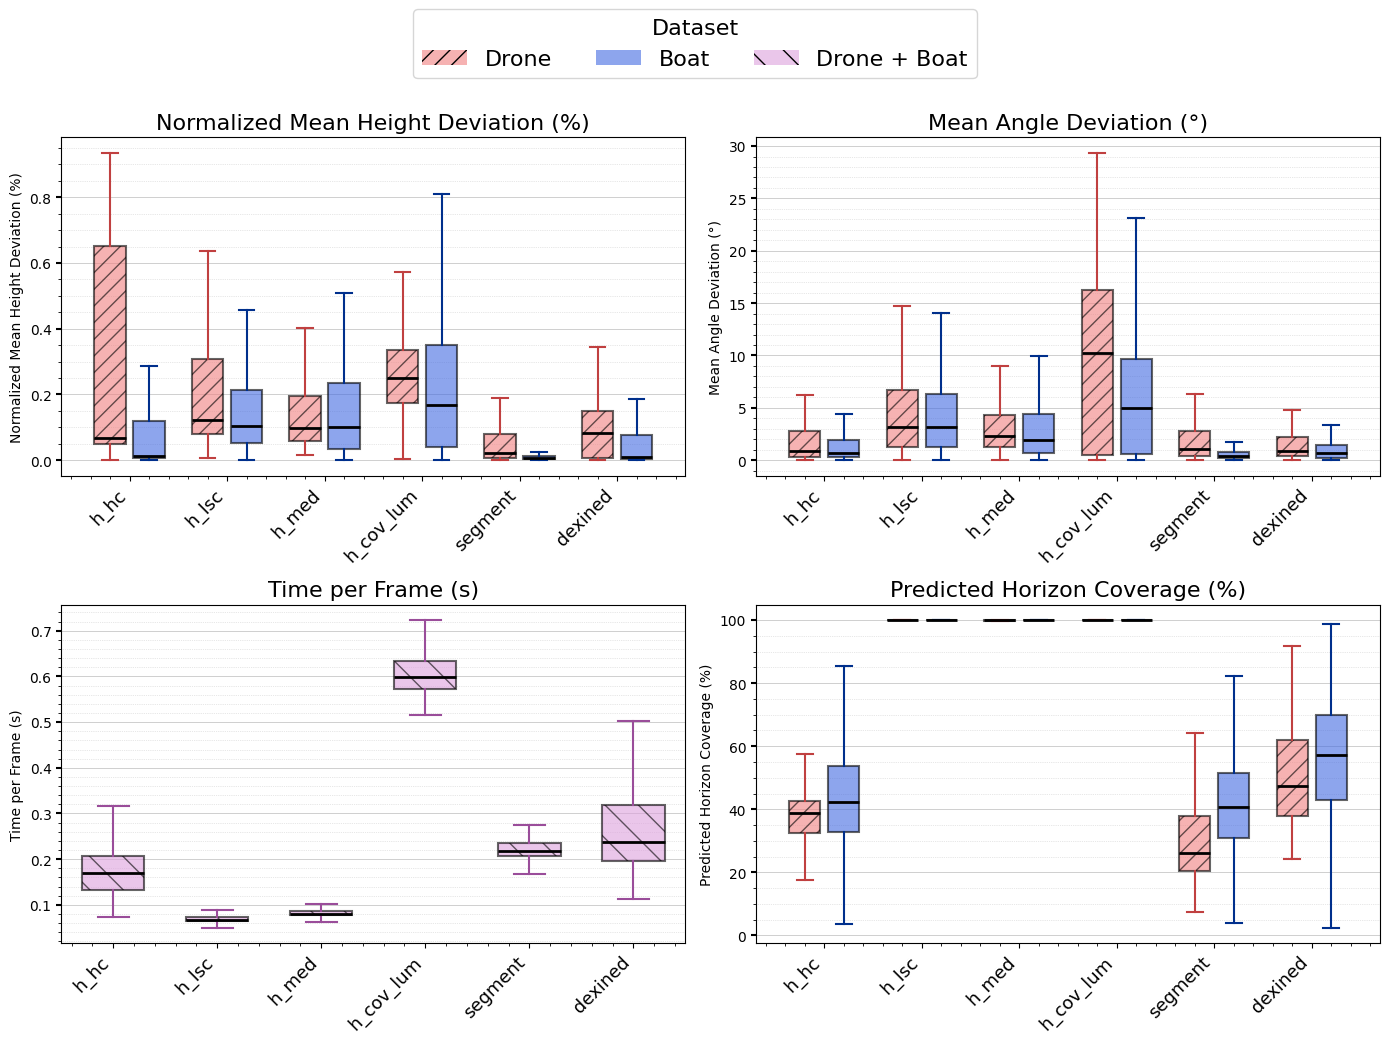

In [ ]:
metrics = [
    ("mean_height_perc_dev", "Normalized Mean Height Deviation (%)"),
    ("mean_angle_deviation", "Mean Angle Deviation (°)"),
    ("time_sec", "Time per Frame (s)"),
    ("predicted_coverage_percent", "Predicted Horizon Coverage (%)")
]

methods = df_concat['method'].unique()
types = ["drone", "boat"]

box_hatch = {"drone": "//", "boat": ""}
box_colors = {"drone":"lightcoral", "boat": "royalblue"}
whisker_colors = {"drone": "#c04040", "boat": "#002f8c"}

# Create a 2x2 grid of subplots
fig, axs = plt.subplots(2, 2, figsize=(14, 10))
axs = axs.flatten()

for ax, (col, ylabel) in zip(axs, metrics):
    x = np.arange(len(methods))
    total_width = 0.8

    for i, m in enumerate(methods):
        if col == "time_sec":
              yvals = df_concat[(df_concat['method']==m)][col].values
              ax.boxplot(
                  yvals,
                  positions=[i],
                  widths=0.6,
                  patch_artist=True,
                  showfliers=False,
                  boxprops=dict(
                      facecolor="plum",
                      hatch="\\",
                      alpha=0.6,
                      linewidth=1.5
                  ),
                  medianprops=dict(color='black', linewidth=2),
                  whiskerprops=dict(color="#9a4d9a", linewidth=1.5),
                  capprops=dict(color="#9a4d9a", linewidth=1.5)
              )
        else:
              separation = total_width / len(types)
              for j, t in enumerate(types):
                  positions = i - total_width/2 + separation/2 + j*separation
                  yvals = df_concat[(df_concat['method']==m) & (df_concat['type']==t)][col].values
                  if len(yvals) == 0:
                      continue
                  ax.boxplot(
                      yvals,
                      positions=[positions],
                      widths=separation*0.8,
                      patch_artist=True,
                      showfliers=False,
                      boxprops=dict(
                          facecolor=box_colors[t],
                          hatch=box_hatch[t],
                          alpha=0.6,
                          linewidth=1.5
                      ),
                      medianprops=dict(color='black', linewidth=2),
                      whiskerprops=dict(color=whisker_colors[t], linewidth=1.5),
                      capprops=dict(color=whisker_colors[t], linewidth=1.5)
                  )

    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=45, ha='right', fontsize=13)
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel,fontsize=16)
    ax.grid(True, which='major', axis='y', linestyle='-', linewidth=0.7, alpha=0.6)
    ax.minorticks_on()
    ax.grid(True, which='minor', axis='y', linestyle=':', linewidth=0.5, alpha=0.6)
    ax.tick_params(axis='y', which='major', colors='black', width=1.5, labelsize=10)

legend_handles = [
    mpatches.Patch(
        facecolor=box_colors["drone"],
        hatch="//",
        alpha=0.6,
        label="Drone"
    ),
    mpatches.Patch(
        facecolor=box_colors["boat"],
        alpha=0.6,
        label="Boat"
    ),
    mpatches.Patch(
        facecolor="plum",
        hatch = "\\",
        alpha=0.6,
        label="Drone + Boat"
    )
]

fig.legend(
    handles=legend_handles,
    title="Dataset",
    title_fontsize=16,
    loc='upper center',
    ncol=3,
    fontsize=16,
    bbox_to_anchor=(0.5, 1.05)
)

plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

# Pairwise Statistical Comparison

We test whether the differences between methods are statistically significant using the **Mann-Whitney U test** for non-parametric data. To control the family-wise error rate when performing multiple comparisons, we apply the **Holm-Bonferroni correction**.

In [ ]:
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

best_methods = ["h_hc", "segment", "dexined", "h_lsc", "h_med", "h_cov_lum"]
metric = "mean_height_perc_dev"

for dataset in ["drone", "boat"]:
    print(f"\nDataset: {dataset}")

    pvals = []
    labels = []

    # First pass: compute all raw p-values
    for best in best_methods:
        for other in methods:
            if best == other:
                continue

            group1 = df_concat[(df_concat['type']==dataset) & (df_concat['method']==best)][metric].values
            group2 = df_concat[(df_concat['type']==dataset) & (df_concat['method']==other)][metric].values


            if metric ==  "predicted_coverage_percent":
                stat, p = mannwhitneyu(group1, group2, alternative="greater")
            else:
                stat, p = mannwhitneyu(group1, group2, alternative="less")

            pvals.append(p)
            labels.append((best, other))

    # Apply Holm correction
    reject, pvals_corrected, _, _ = multipletests(pvals, alpha=0.05, method='holm')

    # Print results
    for (best, other), raw_p, corr_p, rej in zip(labels, pvals, pvals_corrected, reject):
        sig = "YES" if rej else "no"


        if metric ==  "predicted_coverage_percent":
            print(f"{best} > {other}?  raw p={raw_p:.4g},  Holm p={corr_p:.4g},  significant: {sig}")
        else:
            print(f"{best} < {other}?  raw p={raw_p:.4g},  Holm p={corr_p:.4g},  significant: {sig}")



Dataset: drone
h_hc < h_med?  raw p=0.7403,  Holm p=1,  significant: no
h_hc < h_lsc?  raw p=3.863e-06,  Holm p=6.568e-05,  significant: YES
h_hc < h_cov_lum?  raw p=8.019e-30,  Holm p=1.524e-28,  significant: YES
h_hc < segment?  raw p=1,  Holm p=1,  significant: no
h_hc < dexined?  raw p=1,  Holm p=1,  significant: no
segment < h_hc?  raw p=2.889e-164,  Holm p=7.223e-163,  significant: YES
segment < h_med?  raw p=6.519e-225,  Holm p=1.695e-223,  significant: YES
segment < h_lsc?  raw p=4.479e-301,  Holm p=1.254e-299,  significant: YES
segment < h_cov_lum?  raw p=0,  Holm p=0,  significant: YES
segment < dexined?  raw p=2.397e-28,  Holm p=4.315e-27,  significant: YES
dexined < h_hc?  raw p=5.81e-47,  Holm p=1.22e-45,  significant: YES
dexined < h_med?  raw p=6.591e-56,  Holm p=1.45e-54,  significant: YES
dexined < h_lsc?  raw p=1.876e-104,  Holm p=4.501e-103,  significant: YES
dexined < h_cov_lum?  raw p=0,  Holm p=0,  significant: YES
dexined < segment?  raw p=1,  Holm p=1,  signifi

# Draw images with predicted horizon for chosen methods

In [ ]:
image_folder =Path(base_dir) / "all_images"
types = [
    "boat1", "boat2", "boat3",
    "drone1", "drone2", "drone3"
]
num_images_per_type = 2

def get_images_by_pattern(df, pattern, max_n):
    rows = df[df["image_name"].str.contains(pattern, case=False, na=False)]
    return rows.head(max_n)

def draw_horizon(ax, img, x1, y1, x2, y2, title):
    ax.imshow(img)
    ax.plot([x1, x2], [y1, y2], color="red", linewidth=3)
    ax.set_title(title)
    ax.axis("off")

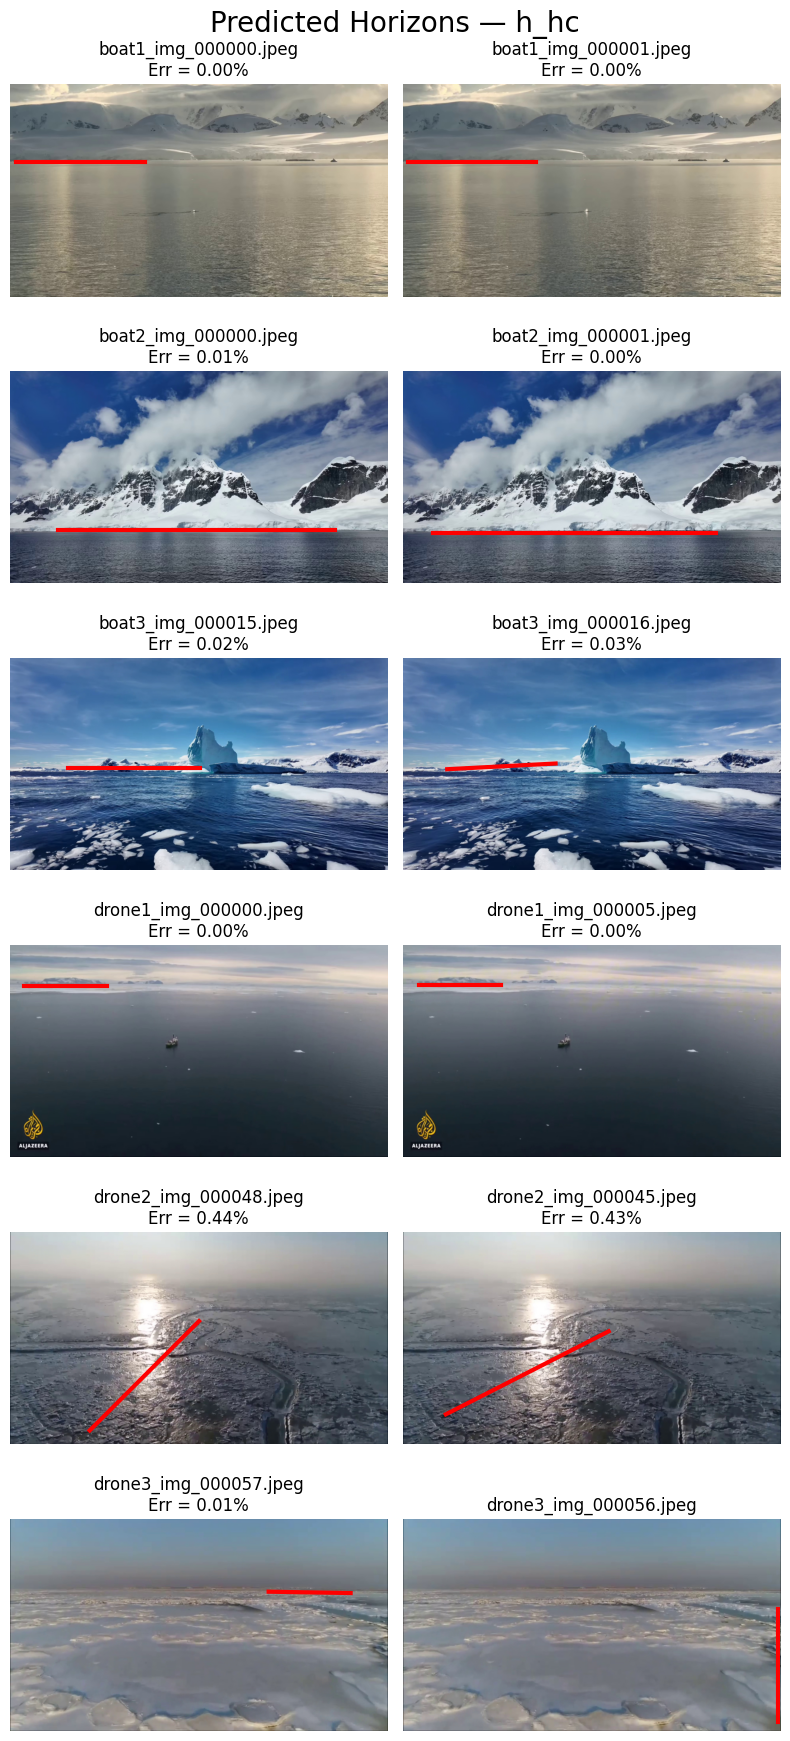

In [ ]:
for method_name in ["h_hc"]:

    df = df_pred[method_name]
    df_err = df_analysis_res[method_name]   # analysis results (errors)


    fig, axes = plt.subplots(
        len(types), num_images_per_type,
        figsize=(num_images_per_type * 4, len(types) * 3)
    )
    fig.suptitle(f"Predicted Horizons — {method_name}", fontsize=20)

    for t_idx, t in enumerate(types):
        subset = get_images_by_pattern(df, t, num_images_per_type)

        for i, (_, row) in enumerate(subset.iterrows()):

            img_path = os.path.join(image_folder, row["image_name"])
            if not os.path.exists(img_path):
                print("Missing image:", img_path)
                continue

            img = cv2.imread(img_path)
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            err_row = df_err[df_err["image_name"] == row["image_name"]]
            if len(err_row) > 0:
                err = err_row["mean_height_perc_dev"].iloc[0]
            else:
                err = None

            ax = axes[t_idx, i]
             # Prepare title
            if err is not None:
                title = f"{row['image_name']}\nErr = {err:.2f}%"
            else:
                title = row["image_name"]


            draw_horizon(
                ax, img,
                row["x1"], row["y1"],
                row["x2"], row["y2"],
                title
            )

    plt.tight_layout()
    plt.show()

# Draw gt horizon on one frame from all videos

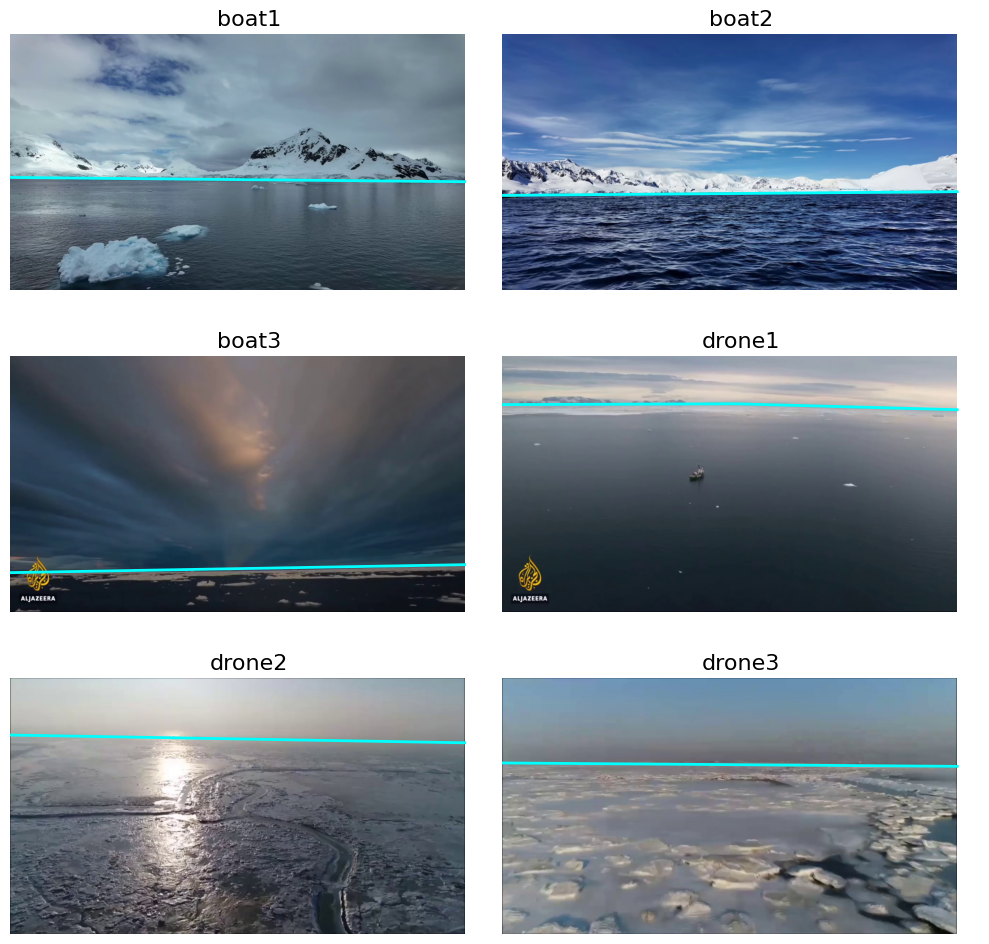

In [ ]:
# Paths
images_folder = Path(base_dir) / "all_images"
df_path = Path(base_dir) / "results_38_videos/horizon_h_hc_analysis_results.csv"
horizon_csv_path = Path(base_dir) / "horizon_gt_coordinates_cropped_all.csv"

# Load CSVs
df = pd.read_csv(df_path)
horizon_df = pd.read_csv(horizon_csv_path)

# Image types
image_types = ['boat1', 'boat2', 'boat3', 'drone1', 'drone2', 'drone3']
plot_labels = image_types
# Collect one sample image per type
sample_images = []
for img_type in image_types:
    filtered = df[df['image_name'].str.contains(img_type)]
    if not filtered.empty:
        img_name = filtered.iloc[0]['image_name']
        img_path = os.path.join(images_folder, img_name)
        if os.path.exists(img_path):
            sample_images.append(img_name)
        else:
            sample_images.append(None)
    else:
        sample_images.append(None)

# Plot images with GT horizon
fig, axs = plt.subplots(3, 2, figsize=(10, 10))
axs = axs.flatten()

for i, img_name in enumerate(sample_images):
    axs[i].axis('off')
    axs[i].set_title(plot_labels[i], fontsize=16)

    if img_name is not None:
        img_path = os.path.join(images_folder, img_name)
        img = cv2.imread(img_path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        axs[i].imshow(img)

        horizon_rows = horizon_df[horizon_df['image_name'] == img_name]
        if not horizon_rows.empty:
            x_vals = horizon_rows['x'].values
            y_vals = horizon_rows['y'].values
            axs[i].plot(x_vals, y_vals, color='cyan', linewidth=2)

plt.tight_layout()
plt.show()

# Draw true and predicted horizon on 1 image from each type

In [ ]:
import pandas as pd
import numpy as np

gt_csv = Path(base_dir) / "horizon_gt_coordinates_cropped_all.csv"
gt_df = pd.read_csv(gt_csv)

gt_dict = {}
for img_name, group in gt_df.groupby("image_name"):
    points = group[["x", "y"]].values.astype(float)
    points = points[np.argsort(points[:, 0])]
    if len(points) >= 2 and np.all(np.isfinite(points)):
        gt_dict[img_name] = points


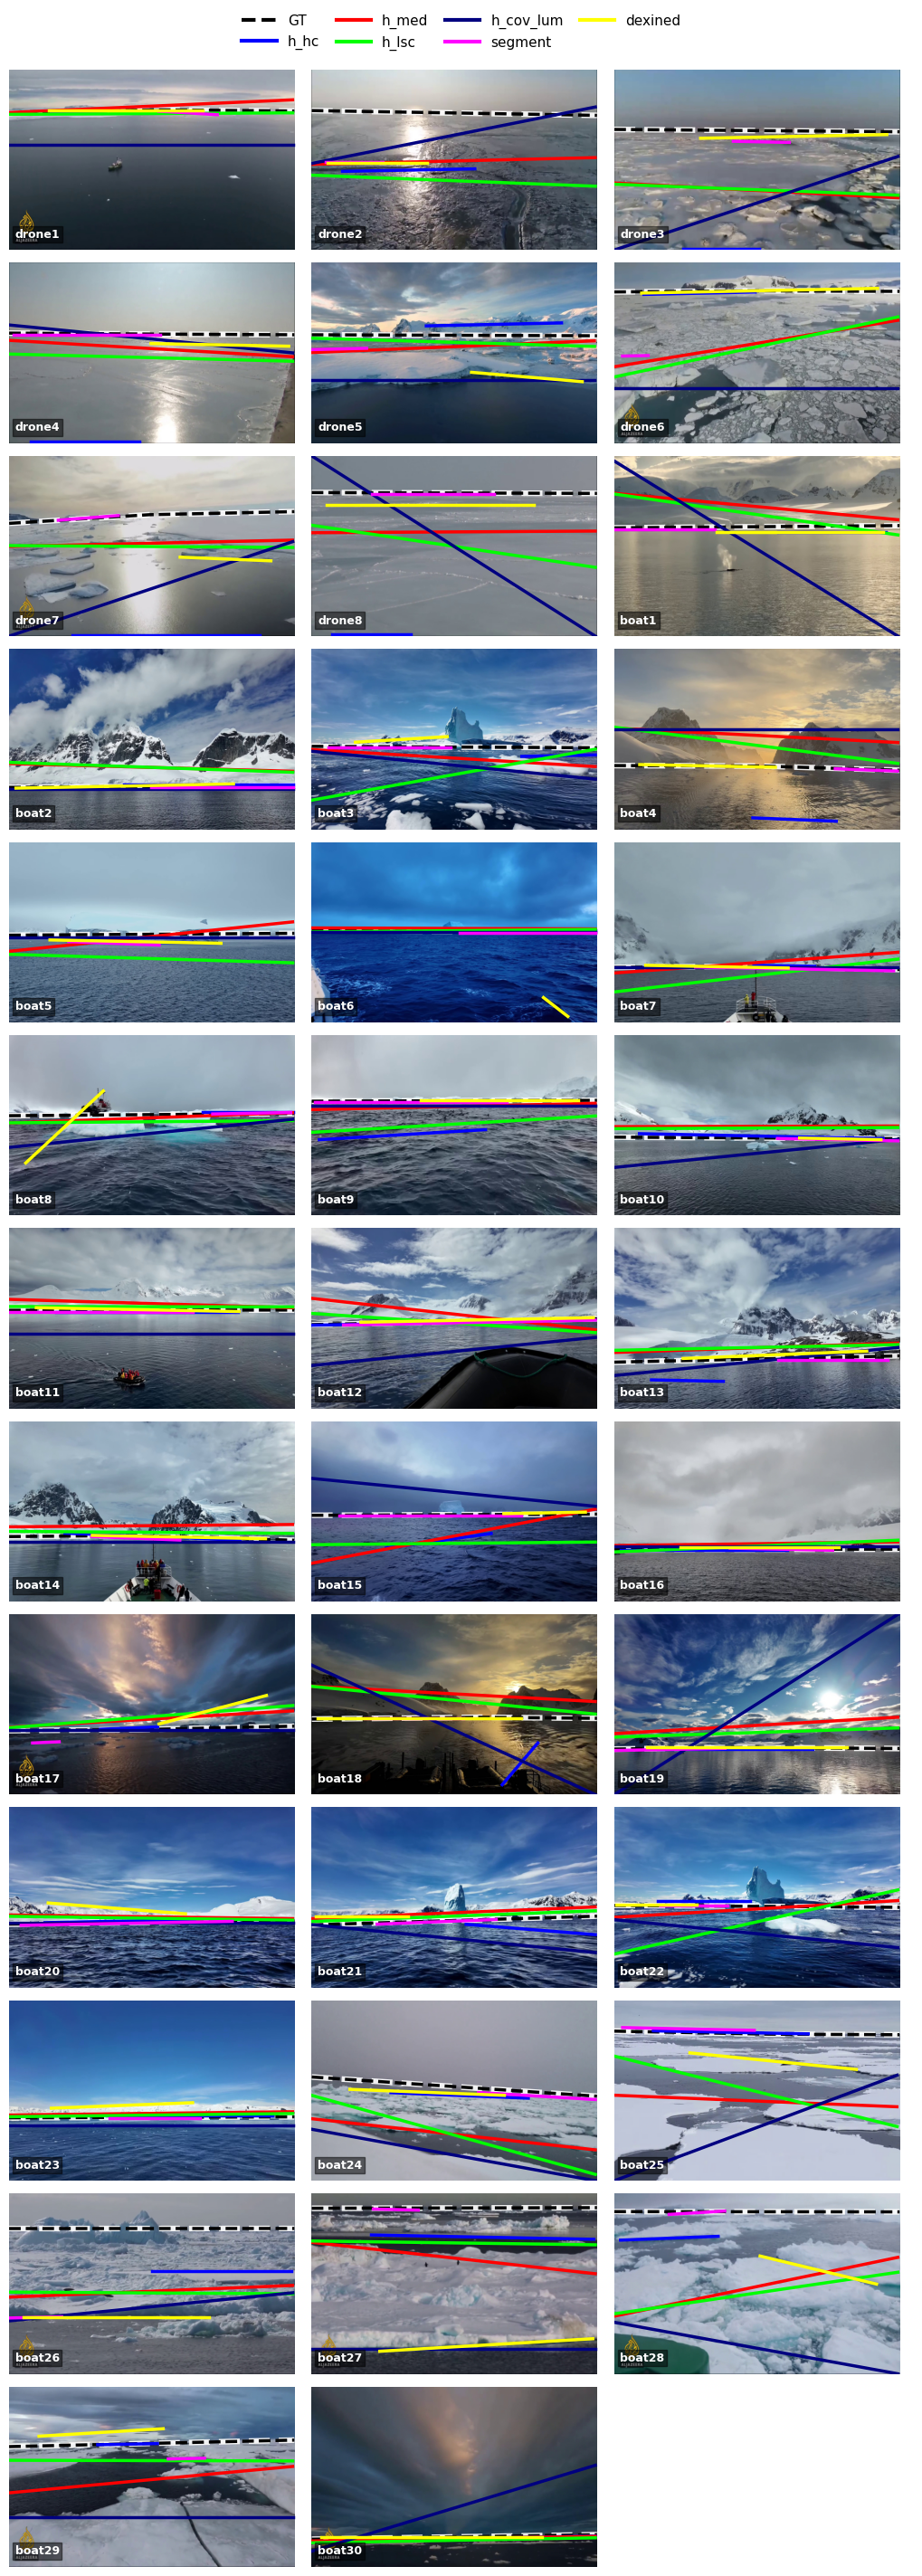

In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

methods = [
    "h_hc",
    "h_med",
    "h_lsc",
    "h_cov_lum",
    "segment",
    "dexined",
]

colors_bgr = [
    (0, 0, 255),
    (255, 0, 0),
    (0, 255, 0),
    (0, 0, 128),
    (255, 0, 255),
    (255, 255, 0),
]

colors = [(b / 255, g / 255, r / 255) for (b, g, r) in colors_bgr]

types = (
    [f"drone{i}" for i in range(1, 9)] +
    [f"boat{i}" for i in range(1, 31)]
)

def get_gt_points(img_name):
    if img_name not in df_gt["image_name"].values:
        return None
    row = df_gt[df_gt["image_name"] == img_name].iloc[0]
    try:
        x1, y1, x2, y2 = map(float, [row.x1, row.y1, row.x2, row.y2])
    except Exception:
        return None
    if not all(v == v for v in [x1, y1, x2, y2]):
        return None
    return np.array([[x1, y1], [x2, y2]])

fig, axes = plt.subplots(13, 3, figsize=(10, 30))
# fig.patch.set_facecolor("#e6e6e6")

axes_flat = axes.flatten()


plt.subplots_adjust(
    left=0,
    right=1,
    top=0.92,
    bottom=0,
    wspace=0.01,
    hspace=0.07
)

for idx, display_type in enumerate(types):
    ax = axes_flat[idx]

    sample_df = df_pred[methods[0]]
    all_matches = sample_df[
        sample_df["image_name"].str.startswith(display_type + "_")
    ]

    if len(all_matches) == 0:
        ax.axis("off")
        continue

    img_name = all_matches.sample(n=1).iloc[0]["image_name"]
    img = cv2.imread(os.path.join(image_folder, img_name))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    ax.imshow(img, zorder=0)
    ax.set_aspect("auto")


    gt_points = gt_dict.get(img_name)
    if gt_points is not None:
        ax.plot(
            gt_points[:, 0], gt_points[:, 1],
            linestyle="--",
            color="white",
            linewidth=4.5,
            alpha=0.9,
            zorder=3
        )
        ax.plot(
            gt_points[:, 0], gt_points[:, 1],
            linestyle="--",
            color="black",
            linewidth=2.5,
            zorder=4
        )

    for method, color in zip(methods, colors):
        row = df_pred[method][df_pred[method]["image_name"] == img_name]
        if len(row) == 0:
            continue
        r = row.iloc[0]
        try:
            x1, y1, x2, y2 = map(float, [r.x1, r.y1, r.x2, r.y2])
        except Exception:
            continue
        if not all(v == v for v in [x1, y1, x2, y2]):
            continue
        ax.plot(
            [x1, x2-10], [y1, y2],
            color=color,
            linewidth=2.5,
            zorder=4
        )

    ax.text(
        0.02, 0.07, display_type,
        transform=ax.transAxes,
        fontsize=9,
        color="white",
        weight="bold",
        bbox=dict(facecolor="black", alpha=0.5, pad=2),
        zorder=7
    )

    ax.axis("off")

for ax in axes_flat[len(types):]:
    ax.axis("off")

legend_handles = [
    Line2D([0], [0], color="black", linestyle="--", linewidth=3, label="GT")
]

for method, color in zip(methods, colors):
    legend_handles.append(
        Line2D([0], [0], color=color, linewidth=3, label=method)
    )

fig.legend(
    handles=legend_handles,
    loc="upper center",
    ncol=4,
    fontsize=11,
    frameon=False,
    columnspacing=1.2,
    handlelength=2.5,
    bbox_to_anchor=(0.5, 0.945)
)

plt.show()


# Make a video of pred and true horizons

In [ ]:
def make_horizon_video(frame_type, df_pred,
    methods, colors_bgr, image_folder,
    output_video, fps=10, line_thickness=3,
    legend_height=70):

    sample_df = df_pred[methods[0]]
    frames_df = sample_df[sample_df["image_name"].str.startswith(frame_type + "_")]
    frames_df = frames_df.sort_values("image_name")

    if len(frames_df) == 0:
        raise ValueError(f"No frames found for '{frame_type}'")

    first_img = cv2.imread(os.path.join(image_folder, frames_df.iloc[0]["image_name"]))
    h, w, _ = first_img.shape

    out_h = h + legend_height
    fourcc = cv2.VideoWriter_fourcc(*"mp4v")
    video = cv2.VideoWriter(output_video, fourcc, fps, (w, out_h))


    font = cv2.FONT_HERSHEY_SIMPLEX
    font_scale = 0.6
    text_thickness = 2

    x_start = 20
    y_mid = legend_height // 2 + 5
    spacing = 180


    def draw_dashed_line(img, p1, p2, color, thickness, dash_len=10):
        dist = int(np.hypot(p2[0] - p1[0], p2[1] - p1[1]))
        for i in range(0, dist, dash_len * 2):
            start = (
                int(p1[0] + (p2[0] - p1[0]) * i / dist),
                int(p1[1] + (p2[1] - p1[1]) * i / dist)
            )
            end = (
                int(p1[0] + (p2[0] - p1[0]) * (i + dash_len) / dist),
                int(p1[1] + (p2[1] - p1[1]) * (i + dash_len) / dist)
            )
            cv2.line(img, start, end, color, thickness, cv2.LINE_AA)


    for row in tqdm(frames_df.itertuples(index=False),
                    total=len(frames_df),
                    desc=f"Rendering {frame_type}"):

        img_name = row.image_name
        frame = cv2.imread(os.path.join(image_folder, img_name))  # BGR

        canvas = np.zeros((out_h, w, 3), dtype=np.uint8)
        canvas[:legend_height, :, :] = (220, 220, 220)  # light gray

        canvas[legend_height:, :, :] = frame

        x = x_start
        draw_dashed_line(canvas, (x, y_mid), (x + 40, y_mid),
              (0, 0, 0), line_thickness)

        cv2.putText(canvas,  "GT",  (x + 50, y_mid + 5), font,
            font_scale,  (0, 0, 0),  text_thickness, cv2.LINE_AA )
        x += spacing

        # Prediction entries
        for method, color in zip(methods, colors_bgr):
            cv2.line(  canvas,   (x, y_mid),  (x + 40, y_mid),
                color,  thickness=line_thickness, lineType=cv2.LINE_AA  )
            cv2.putText(
                canvas,  method,  (x + 50, y_mid + 5),
                font,  font_scale, (0,0,0),
                text_thickness, cv2.LINE_AA )
            x += spacing

        gt_points = get_gt_points(img_name)
        if gt_points is not None:
            pts = gt_points.astype(int).reshape(-1, 1, 2)
            pts[:, :, 1] += legend_height
            draw_dashed_line(
                canvas,
                tuple(pts[0, 0]),
                tuple(pts[-1, 0]),
                (0, 0, 0),
                line_thickness
            )

        # ---- Predictions ----
        for method, color in zip(methods, colors_bgr):
            if method not in df_pred:
                continue

            pred_df = df_pred[method]
            r = pred_df[pred_df["image_name"] == img_name]
            if len(r) == 0:
                continue

            r = r.iloc[0]
            try:
                x1, y1, x2, y2 = map(float, [r.x1, r.y1, r.x2, r.y2])
            except ValueError:
                continue
            if not all(map(math.isfinite, [x1, y1, x2, y2])):
                continue

            cv2.line(
                canvas,
                (int(x1), int(y1 + legend_height)),
                (int(x2), int(y2 + legend_height)),
                color,
                thickness=line_thickness,
                lineType=cv2.LINE_AA
            )

        video.write(canvas)

    video.release()
    print(f"Video saved: {output_video}")


methods = ["h_hc", "h_med", "h_lsc", "h_cov_lum", "segment", "dexined"]
colors_bgr = [(0, 0, 255),    # Red - H-HC
              (255, 0, 0),    # Blue - H-MED
              (0, 255, 0),    # Lime - H-LSC
              (0, 0, 128),    # Maroon - H-COV-LUM
              (255, 0, 255),  # Magenta - SEGMENT
              (255, 255, 0)]  # Cyan - DEXINED
image_folder = Path(base_dir)/ "all_images"

for i in range(1, 9):
    frame_type = f"drone{i}"

    print(f"\n=== Processing {frame_type} ===")

    make_horizon_video(
        frame_type=frame_type,
        df_pred=df_pred,
        methods=methods,
        colors_bgr=colors_bgr,
        image_folder=image_folder,
        output_video=Path(base_dir)/f"videos_res/{frame_type}_horizons.mp4",
        fps=15
    )
